In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [3]:
df=pd.read_csv("Salary_dataset.csv")

In [4]:
df.head(5)

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [5]:
df.dropna(inplace = True)

In [6]:
df.isnull().sum

<bound method DataFrame.sum of     Unnamed: 0  YearsExperience  Salary
0        False            False   False
1        False            False   False
2        False            False   False
3        False            False   False
4        False            False   False
5        False            False   False
6        False            False   False
7        False            False   False
8        False            False   False
9        False            False   False
10       False            False   False
11       False            False   False
12       False            False   False
13       False            False   False
14       False            False   False
15       False            False   False
16       False            False   False
17       False            False   False
18       False            False   False
19       False            False   False
20       False            False   False
21       False            False   False
22       False            False   False
23       

In [7]:
df.shape

(30, 3)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [9]:
# correlation check
df.corr()

,Unnamed: 0,YearsExperience,Salary
Unnamed: 0,1.000000,0.986460,0.960826
YearsExperience,0.986460,1.000000,0.978242
Salary,0.960826,0.978242,1.000000


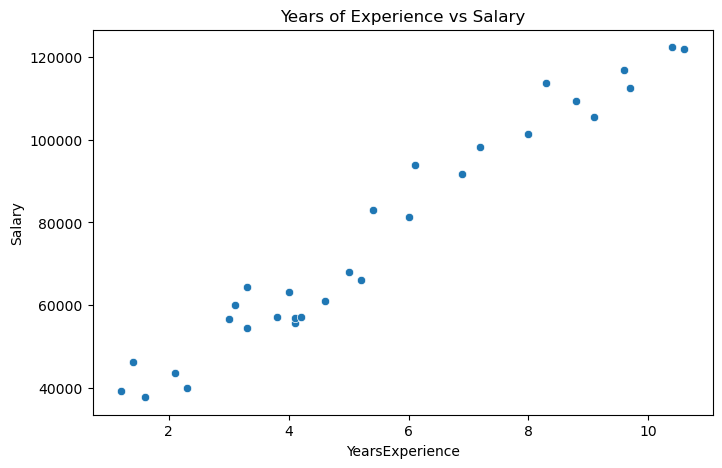

In [10]:
# scatter plot
plt.figure(figsize=(8,5))
sns.scatterplot(x='YearsExperience', y='Salary', data=df)
plt.title('Years of Experience vs Salary')
plt.show()

# Step 4 Target variables Select(x,y)

In [38]:
x =df[['YearsExperience']]
y =df['Salary']

# Step 5 Train-Test Split

In [39]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# step 6 Import Model(Linear Regression)

In [40]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

# step 7 Training (fit)

In [41]:
lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
# coefficient and  intercept 
print("Coefficient (m):", lr.coef_)
print("Intercept (c):", lr.intercept_)

Coefficient (m): [9423.81532303]
Intercept (c): 24380.20147947369


# step 8 Prediction

In [43]:
y_pred = lr.predict(x_test)
y_pred

array([115791.21011287,  71499.27809463, 102597.86866063,  75268.80422384,
        55478.79204548,  60190.69970699])

In [44]:
# actual vs predicted 
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
comparison

,Actual,Predicted
27,112636.0,115791.210113
15,67939.0,71499.278095
23,113813.0,102597.868661
17,83089.0,75268.804224
8,64446.0,55478.792045
9,57190.0,60190.699707


# Step 9 Model Evaluation

In [45]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R2 Score:", r2)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

R2 Score: 0.9024461774180498
Mean Squared Error: 49830096.855908334
Mean Absolute Error: 6286.453830757745
Root Mean Squared Error: 7059.043621901506


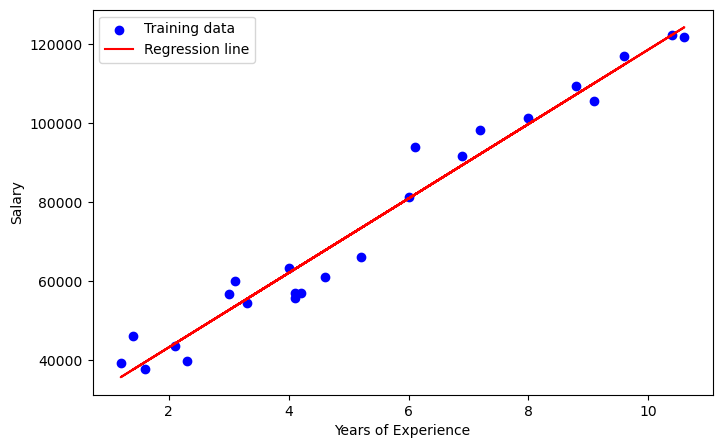

In [46]:
# visualize regression line
plt.figure(figsize=(8,5))
plt.scatter(x_train, y_train, color='blue', label='Training data')
plt.plot(x_train, lr.predict(x_train), color='red', label='Regression line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

# Step 10 Convert Model into PKL file

In [47]:
import pickle

with open('salary_model.pkl', 'wb') as file:
    pickle.dump(lr, file)

print("Model saved as salary_model.pkl")

Model saved as salary_model.pkl


# Frontened/GUI